In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data/Pokemon.csv")
df

,number,name,type1,type2,total,hp,attack,defense,sp_attack,sp_defense,speed,generation,legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,Mega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,3,Gigantamax Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067,896,Glastrier,Ice,NaN,580,100,145,130,65,110,30,8,True
1068,897,Spectrier,Ghost,NaN,580,100,65,60,145,80,130,8,True
1069,898,Calyrex,Psychic,Grass,500,100,80,80,80,80,80,8,True
1070,898,Ice Rider Calyrex,Psychic,Ice,680,100,165,150,85,130,50,8,True


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1072 entries, 0 to 1071
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   number      1072 non-null   int64
 1   name        1072 non-null   str  
 2   type1       1072 non-null   str  
 3   type2       574 non-null    str  
 4   total       1072 non-null   int64
 5   hp          1072 non-null   int64
 6   attack      1072 non-null   int64
 7   defense     1072 non-null   int64
 8   sp_attack   1072 non-null   int64
 9   sp_defense  1072 non-null   int64
 10  speed       1072 non-null   int64
 11  generation  1072 non-null   int64
 12  legendary   1072 non-null   bool 
dtypes: bool(1), int64(9), str(3)
memory usage: 120.3 KB


In [4]:
df = pd.DataFrame(df)
df.head()
column_list = list(df.columns)
column_list

['number',
 'name',
 'type1',
 'type2',
 'total',
 'hp',
 'attack',
 'defense',
 'sp_attack',
 'sp_defense',
 'speed',
 'generation',
 'legendary']

In [5]:
df.drop(columns='number',inplace=True)
df.head()

,name,type1,type2,total,hp,attack,defense,sp_attack,sp_defense,speed,generation,legendary
0,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,Mega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Gigantamax Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False


In [6]:
df.tail()

,name,type1,type2,total,hp,attack,defense,sp_attack,sp_defense,speed,generation,legendary
1067,Glastrier,Ice,NaN,580,100,145,130,65,110,30,8,True
1068,Spectrier,Ghost,NaN,580,100,65,60,145,80,130,8,True
1069,Calyrex,Psychic,Grass,500,100,80,80,80,80,80,8,True
1070,Ice Rider Calyrex,Psychic,Ice,680,100,165,150,85,130,50,8,True
1071,Shadow Rider Calyrex,Psychic,Ghost,680,100,85,80,165,100,150,8,True


In [7]:
df['type1'] = df['type1'].replace('Blastoise', 'Water') # blatoise is mistakenly in type1
df['name'] = df['name'].replace('Gigantamax Blasoise', 'Gigantamax Blastoise') # wrong spelling
df.loc[df['name'] == 'Gigantamax Blastoise', 'type2'] = 'None'
print(df[df['name'] == 'Gigantamax Blastoise'][['name','type1','type2']])

                    name  type1 type2
15  Gigantamax Blastoise  Water  None


In [8]:
df['generation'] = df['generation'].replace(0,1) #noticed the min value is 0

In [9]:
df.describe()

,total,hp,attack,defense,sp_attack,sp_defense,speed,generation
count,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000
mean,440.885261,70.486940,80.938433,74.968284,73.273321,72.476679,68.792910,4.297575
std,121.379077,26.868039,32.463582,31.208059,32.643119,27.934253,30.076281,2.341936
min,175.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.000000
25%,330.000000,50.000000,56.000000,52.000000,50.000000,50.000000,45.000000,2.000000
50%,460.500000,68.000000,80.000000,70.000000,65.000000,70.000000,65.000000,4.000000
75%,519.250000,84.000000,100.000000,90.000000,95.000000,90.000000,90.000000,6.000000
max,1125.000000,255.000000,190.000000,250.000000,194.000000,250.000000,200.000000,8.000000


In [10]:
# replace N/A in the type2 column
df['type2'] = df['type2'].fillna('None')

In [11]:
df['type1'] = df['type1'].replace('Graass','Grass')

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

name          0
type1         0
type2         0
total         0
hp            0
attack        0
defense       0
sp_attack     0
sp_defense    0
speed         0
generation    0
legendary     0
dtype: int64

In [14]:
df.nunique()

name          1072
type1           18
type2           19
total          219
hp             103
attack         123
defense        114
sp_attack      119
sp_defense     107
speed          127
generation       8
legendary        2
dtype: int64

# Data Visualization

## Distribution of Elemental Types

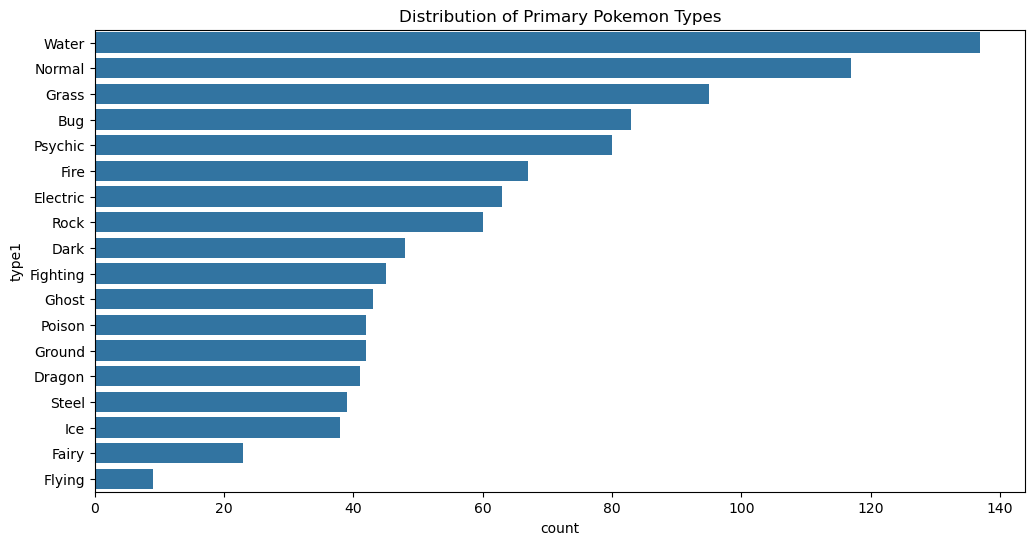

In [15]:
primary_type_counts = df['type1'].value_counts()

plt.figure(figsize=(12,6))
sns.countplot(y='type1', data=df, order=primary_type_counts.index)
plt.title("Distribution of Primary Pokemon Types")
plt.show()

In [16]:
legendary_type1 = df[df['legendary'] == True]['type1'].value_counts()
print(legendary_type1)

type1
Psychic     30
Dragon      15
Fighting     9
Water        9
Steel        8
Electric     7
Fire         5
Dark         5
Rock         4
Ground       4
Normal       4
Grass        4
Ice          3
Ghost        3
Fairy        3
Flying       2
Poison       2
Bug          1
Name: count, dtype: int64


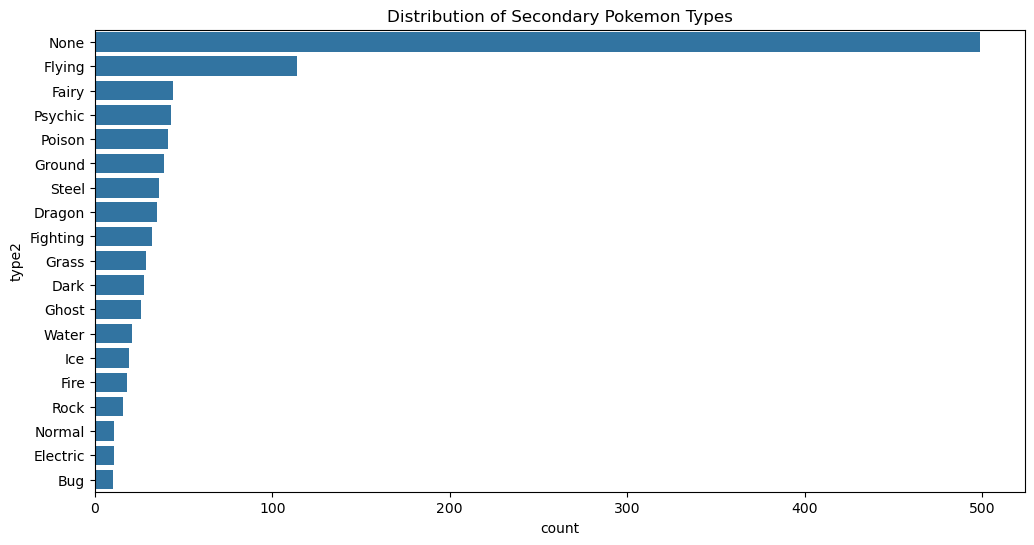

In [17]:
secondary_type_counts = df['type2'].value_counts()

plt.figure(figsize=(12,6))
sns.countplot(y='type2', data=df, order=secondary_type_counts.index)
plt.title("Distribution of Secondary Pokemon Types")
plt.show()

In [18]:
legendary_type2 = df[df['legendary'] == True]['type2'].value_counts()
print(legendary_type2)

type2
None        43
Flying      16
Fighting     7
Dragon       7
Fairy        7
Psychic      6
Steel        6
Ghost        5
Grass        4
Ice          4
Fire         3
Ground       3
Dark         3
Water        3
Electric     1
Name: count, dtype: int64


In [19]:
legendary_types = df[df['legendary']].groupby(['type1','type2']).size().sort_values(ascending=False)
print(legendary_types)

type1    type2   
Psychic  None        14
Water    None         5
Steel    None         4
Dragon   Psychic      4
Psychic  Ghost        4
                     ..
Steel    Fairy        1
         Psychic      1
         Fighting     1
Water    Fairy        1
         Dragon       1
Length: 65, dtype: int64


In [20]:
print(df["legendary"].value_counts())

legendary
False    954
True     118
Name: count, dtype: int64


## Generation Trends

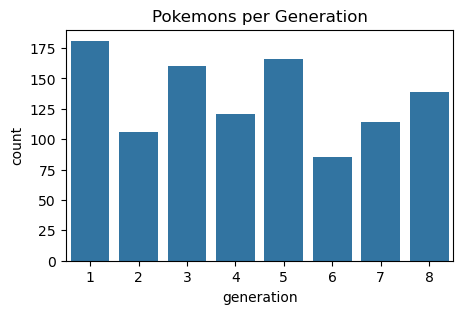

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(5,3))
sns.countplot(data=df, x="generation", ax=ax)

plt.title("Pokemons per Generation")
plt.show()

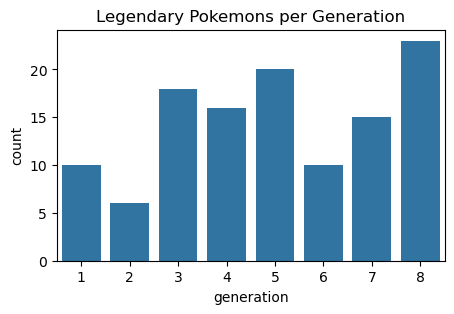

In [22]:
generation_stats = (
    df[df['legendary']].groupby('generation').size().reset_index(name='count')
)

fig, ax = plt.subplots(1, 1, figsize=(5,3))
sns.barplot(data=generation_stats, x='generation', y='count', ax=ax)

plt.title("Legendary Pokemons per Generation")
plt.show()

## Correlations between Attributes

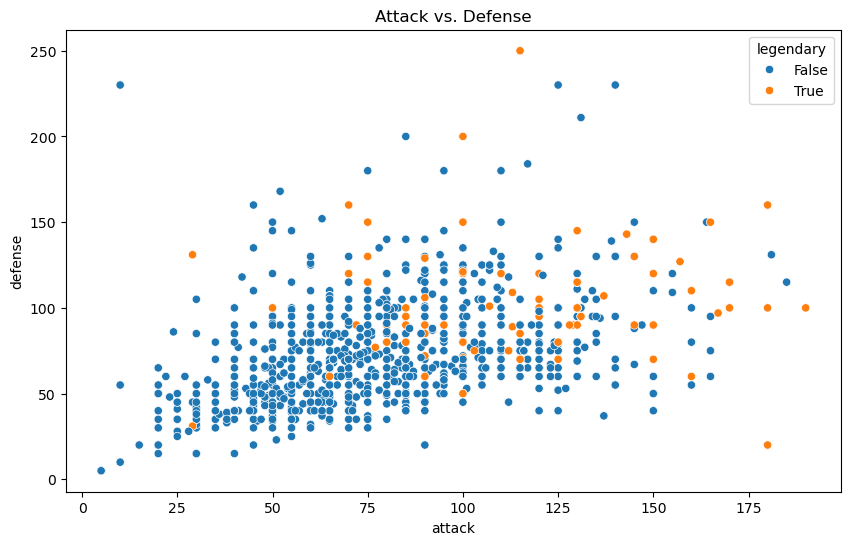

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="attack",
    y="defense",
    hue="legendary"
)

plt.title("Attack vs. Defense")
plt.show()

In [24]:
df["attack"].corr(df["defense"])

np.float64(0.46060323862634805)

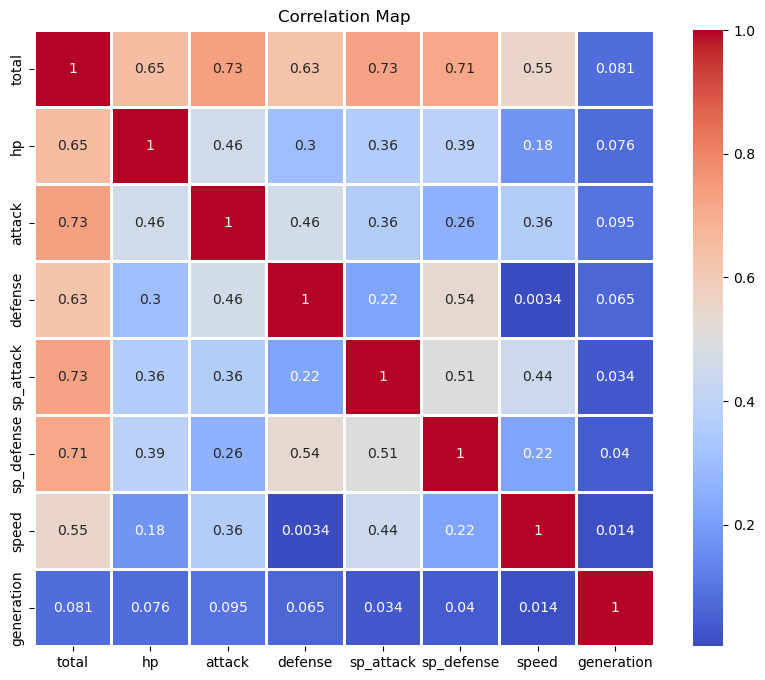

In [25]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    linewidths=True,
    cmap='coolwarm'
)

plt.title("Correlation Map")
plt.show()

#### Pearson Correlation Coefficient Table
<table>
  <tr>
    <th>Scale of Correlation Coefficient</th>
    <th>Value</th>
  </tr>
  <tr>
    <td>0 < r <= 0.19</td>
    <td>Very Low Correlation</td>
  </tr>
  <tr>
    <td>0.2 < r <= 0.39</td>
    <td>Low Correlation</td>
  </tr>
  <tr>
    <td>0.4 < r <= 0.59</td>
    <td>Moderate Correlation</td>
  </tr>
  <tr>
    <td>0.6 < r <= 0.79</td>
    <td>High Correlation</td>
  </tr>
  <tr>
    <td>0.8 < r <= 1</td>
    <td>Very High Correlation</td>
  </tr>
</table>
